<a href="https://colab.research.google.com/github/rafaelrubo/extensao-cs-qualidade-do-ar/blob/main/extens%C3%A3o_qualidade_do_ar3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# INSTALAÇÃO DAS BIBLIOTECAS
# ============================================================
!pip install pandas scikit-learn matplotlib openpyxl -q

In [ ]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

from scipy.stats import pearsonr

from google.colab import files

In [ ]:
# ============================================================
# UPLOAD DO ARQUIVO
# ============================================================
uploaded = files.upload()

arquivo = list(uploaded.keys())[0]

Saving 20270427 - medidas.xlsx to 20270427 - medidas.xlsx


In [ ]:
# ============================================================
# LEITURA DA PLANILHA
# ============================================================
df = pd.read_excel(
    arquivo,
    header=1
)

In [ ]:
# ============================================================
# REMOVER LINHAS VAZIAS
# ============================================================
df = df[df['Ponto'].notna()].copy()

In [ ]:
# ============================================================
# GARANTIR NUMÉRICOS
# ============================================================
colunas_numericas = [
    'CO₂ (ppm)',
    'HCHO (mg/m³)',
    'TVOC (mg/m³)',
    'IQA Google'
]

for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# ============================================================
# MANTER APENAS LINHAS COM IQA GOOGLE
# (As 14 observações)
# ============================================================
df = df[df['IQA Google'].notna()].copy()

In [ ]:
# ============================================================
# DEFINIR VARIÁVEIS
# ============================================================
X = df[
    [
        'CO₂ (ppm)',
        'HCHO (mg/m³)',
        'TVOC (mg/m³)'
    ]
]

y = df['IQA Google']

In [ ]:
# ============================================================
# PADRONIZAÇÃO
# ============================================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# ============================================================
# AJUSTE DA REGRESSÃO
# ============================================================
modelo = LinearRegression()

modelo.fit(X_scaled, y)

LinearRegression()

In [ ]:
# ============================================================
# PREVISÕES
# ============================================================
y_pred = modelo.predict(X_scaled)

In [ ]:
# ============================================================
# MÉTRICAS
# ============================================================
r2 = r2_score(y, y_pred)

rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)

pearson, pvalor = pearsonr(y, y_pred)

In [ ]:
# ============================================================
# EXIBIR RESULTADOS
# ============================================================
print('\n================ RESULTADOS ================\n')

print('Equação do modelo:\n')

print(
    f'IQA_estimado = '
    f'{modelo.intercept_:.3f}'
    f' + ({modelo.coef_[0]:.3f} * CO2_padronizado)'
    f' + ({modelo.coef_[1]:.3f} * HCHO_padronizado)'
    f' + ({modelo.coef_[2]:.3f} * TVOC_padronizado)'
)

print('\n-------------------------------------------')

print(f'R²: {r2:.4f}')

print(f'RMSE: {rmse:.4f}')

print(f'Correlação de Pearson: {pearson:.4f}')

print(f'p-valor: {pvalor:.6f}')

print('\n===========================================\n')


================ RESULTADOS ================

Equação do modelo:

IQA_estimado = 37.286 + (2.978 * CO2_padronizado) + (-13.193 * HCHO_padronizado) + (14.137 * TVOC_padronizado)

-------------------------------------------
R²: 0.1887
RMSE: 7.9870
Correlação de Pearson: 0.4344
p-valor: 0.120603




In [ ]:
# ============================================================
# ADICIONAR RESULTADOS AO DATAFRAME
# ============================================================
df['IQA Estimado'] = y_pred

In [ ]:
# ============================================================
# CLASSIFICAÇÃO DO ÍNDICE ESTIMADO
# ============================================================
def classificar_iqa(valor):

    if valor <= 40:
        return 'Verde'

    elif valor <= 80:
        return 'Amarelo'

    else:
        return 'Acima da escala'


df['Classe Estimada'] = (
    df['IQA Estimado']
    .apply(classificar_iqa)
)

In [ ]:
# ============================================================
# MOSTRAR TABELA FINAL
# ============================================================
resultado = df[
    [
        'Ponto',
        'Ambiente',
        'CO₂ (ppm)',
        'HCHO (mg/m³)',
        'TVOC (mg/m³)',
        'IQA Google',
        'IQA Estimado',
        'Classe Estimada'
    ]
]

print(resultado)

    Ponto                 Ambiente  CO₂ (ppm)  HCHO (mg/m³)  TVOC (mg/m³)  \
0       1           estacionamento       1005         0.055         0.140   
6       7                  externo       1090         0.152         0.384   
9      10                  externo       1029         0.124         0.312   
10     11           estacionamento        441         0.003         0.007   
13     14           estacionamento        440         0.001         0.007   
14     15           estacionamento       1050         0.125         0.315   
16     17           estacionamento        442         0.001         0.008   
18     19           estacionamento        462         0.017         0.050   
19     20   posto de abastecimento        457         0.019         0.055   
20     21  posto da concessionária        787         0.034         0.091   
21     22           estacionamento        938         0.091         0.231   
22     23  posto da concessionária        520         0.029         0.076   

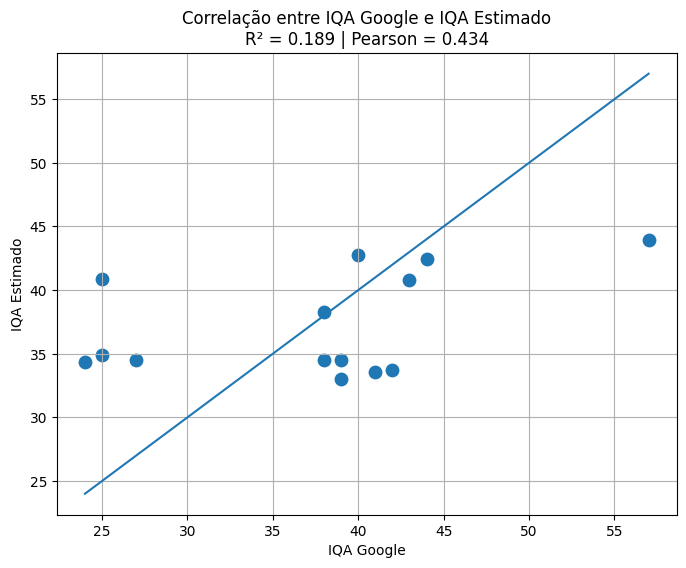

In [ ]:
# ============================================================
# GRÁFICO DE DISPERSÃO
# ============================================================
plt.figure(figsize=(8,6))

plt.scatter(
    y,
    y_pred,
    s=80
)

# Linha ideal y=x
minimo = min(
    y.min(),
    y_pred.min()
)

maximo = max(
    y.max(),
    y_pred.max()
)

plt.plot(
    [minimo, maximo],
    [minimo, maximo]
)

plt.xlabel('IQA Google')

plt.ylabel('IQA Estimado')

plt.title(
    f'Correlação entre IQA Google e IQA Estimado\n'
    f'R² = {r2:.3f} | Pearson = {pearson:.3f}'
)

plt.grid(True)

plt.show()

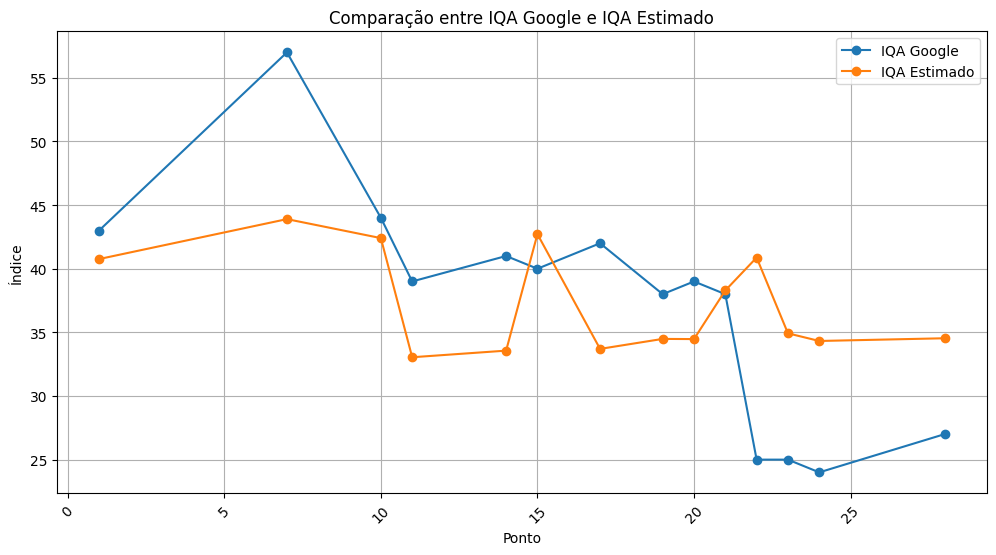

In [ ]:
# ============================================================
# GRÁFICO COMPARATIVO POR PONTO
# ============================================================
plt.figure(figsize=(12,6))

plt.plot(
    df['Ponto'],
    df['IQA Google'],
    marker='o',
    label='IQA Google'
)

plt.plot(
    df['Ponto'],
    df['IQA Estimado'],
    marker='o',
    label='IQA Estimado'
)

plt.xlabel('Ponto')

plt.ylabel('Índice')

plt.title('Comparação entre IQA Google e IQA Estimado')

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================================
# EXPORTAR RESULTADOS
# ============================================================
saida = 'resultado_iqa_estimado.xlsx'

resultado.to_excel(
    saida,
    index=False
)

print(f'\nArquivo salvo: {saida}')


Arquivo salvo: resultado_iqa_estimado.xlsx


In [ ]:
# ============================================================
# DOWNLOAD
# ============================================================
files.download(saida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>